# Lab077 · Single-table ceiling: an information audit

**Learning contract:** build and certify an aggregation collision, then repair it while holding the learner fixed. Tier C synthetic data is required to prove the finite-support claim. Full reproduction: 1,000 pairs × five seeds, executed after EXIT; no scaled-down benchmark substitute.

[Lesson](../lessons/0077-single-table-ceiling.html) · [Reproduction protocol](../labs/l077-reproduction.md)

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Start with retrieval

Before reading further, answer from memory: what did the L035 aggregation discard? Why can an old event be unavailable at prediction time? In L076, which operation decides what a customer can receive from other rows?



Your tangible win is a **ceiling certificate**: two different histories, one identical input vector, incompatible labels, and a calculation showing the best possible accuracy from that vector. You will then break the collision with a feature computed from the eligible history.

This strengthens the mission by making the relational thesis falsifiable. You must name the information a model receives before interpreting its score. The [Fey et al. position paper](https://proceedings.mlr.press/v235/fey24a.html) motivates learning over connected database records. Here we test one carefully bounded consequence of discarding information.

> **Scope check.** This curriculum unit is an original synthesis experiment, with no newly introduced model or assigned published table. Its complete experiment is reproduced below. The construction establishes a possibility and an information bound; it does not measure the prevalence of this problem in real databases.



## 1 · Two histories become the same row

**A representation** is the information passed to a predictor. A predictor maps that information to a label or probability. In this lesson it receives one fixed vector for each customer. Customer IDs, input positions, pair IDs and other customers' records are excluded from that vector.

**Worked example.** Customer A has amounts 10, 30, 50 on days 1, 2, 3. Customer B has 50, 30, 10 on the same days. Both have the same own-row feature. Let the label be 1 when the final eligible amount exceeds the first, otherwise 0. These labels describe a historical pattern, so we can inspect their correctness directly.

For each history, count = 3, sum = 90, mean = 30, maximum = 50. Our flat representation is `[own, count, sum, mean, max]`. It gives A and B the same vector, although their labels differ.



<figure class="ceiling-figure"><div tabindex="0" role="region" aria-label="Scrollable collision figure">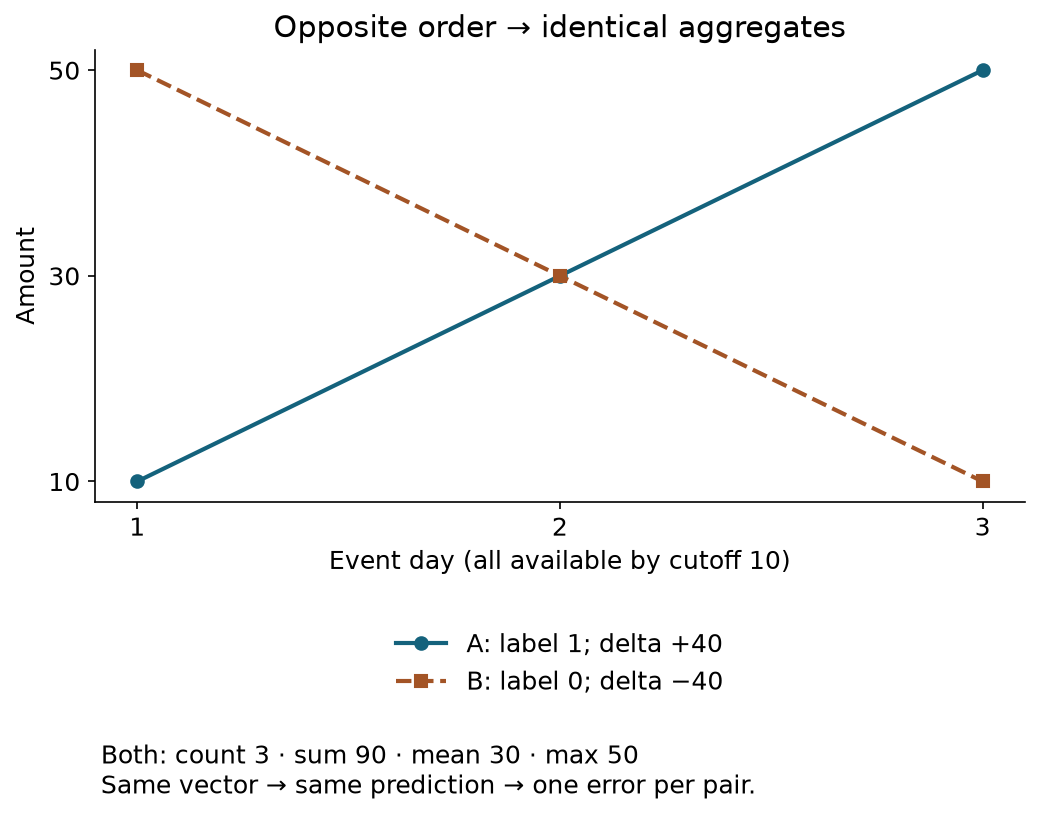</div><figcaption>Worked example: the same three eligible amounts in opposite time order. Count, sum, mean and maximum coincide; last-minus-first has opposite signs.</figcaption></figure>

**A collision** occurs when different underlying records map to the same representation. A join can retain both histories as multiple ordered records. The information loss here occurs in the chosen aggregation, which discards event order. A single-table layout can preserve the missing information if we choose richer columns.

The L035 visual below also varies product identity. Use it as a retrieval exercise: identify which displayed columns collide and which recovered columns distinguish the customers. Our new experiment varies time order only, isolating a single cause.

<div class="ceiling-scroll"></div>



## 2 · Prove the ceiling before training

> **In plain terms.** A predictor that sees the same input must make the same deterministic prediction. If half the customers sharing that input need label 0 and half need label 1, it must miss half of them.

Let `z = F(H)` be the flat vector produced by aggregation `F` from history `H`. A **collision class** is the collection of examples with the same `z`. Write `n(z,0)` and `n(z,1)` for the counts of their two labels. Let `N` be the total number of examples.

For a given class, predicting 0 gets `n(z,0)` correct. Predicting 1 gets `n(z,1)` correct. The best choice therefore gets `max(n(z,0), n(z,1))` correct. Summing these independent choices gives the exact empirical upper bound:

`best accuracy using z alone = Σ_z max(n(z,0), n(z,1)) / N`.

This bound allows **any** mapping from vectors to labels. A particular trained model may perform worse. The calculation uses labels to audit information after the model is frozen; the classifier never receives those test labels.

**Worked example.** One class has labels `[0,0,1]`; another contains `[1]`. The ceiling is `(2 + 1) / 4 = 0.75`. Balanced classes give 0.5. Merely finding one collision does not establish a 0.5 ceiling for the entire dataset.



<figure class="ceiling-figure"><div tabindex="0" role="region" aria-label="Scrollable bound figure">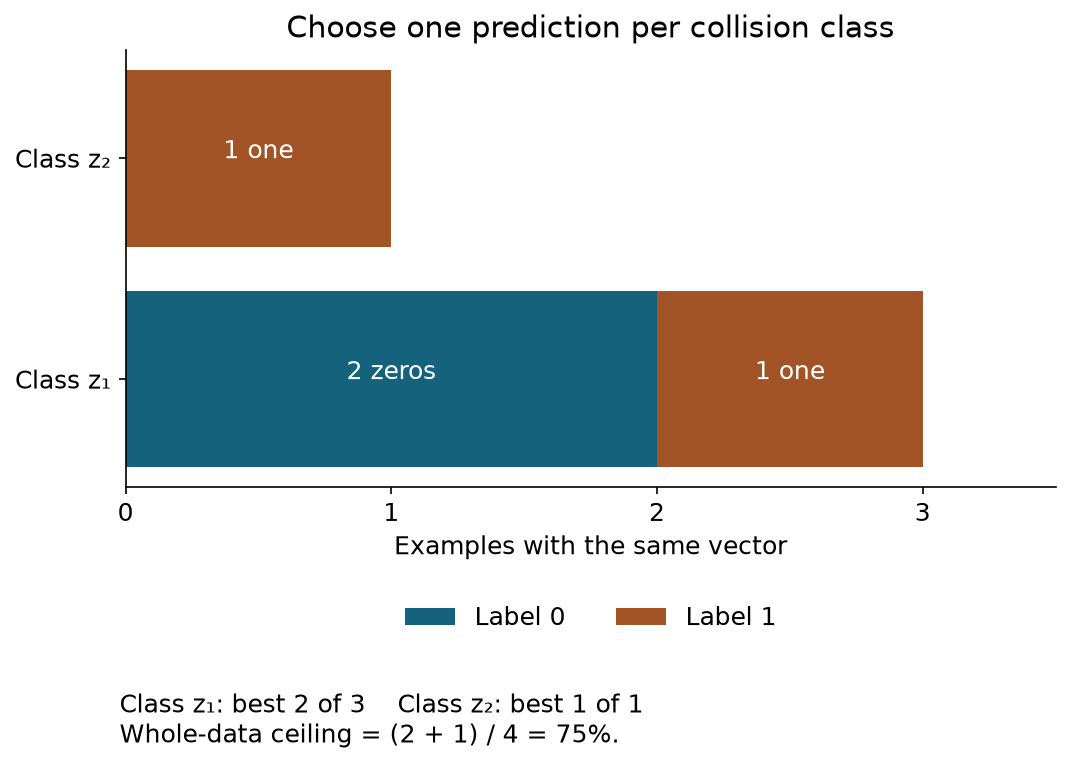</div><figcaption>Four-example illustration, distinct from the balanced experiment. Each collision class gets one prediction: majority counts 2 and 1 give 75% overall.</figcaption></figure>

**Random predictions.** If a balanced collision class receives probability `q` of predicting 1, expected accuracy is `0.5q + 0.5(1−q) = 0.5`. Independent randomized predictions can score above 0.5 on a finite draw, but cannot exceed it in expectation. Our measured classifiers are deterministic. Allowing a row index or unique ID changes the information interface and invalidates this particular bound.

**A population statement.** For our generator, every base history has an equally likely forward and reverse version. Its flat vector is identical in the two cases, so `P(label=1 | z)=0.5`. This establishes the same bound for that defined distribution. On arbitrary real continuous features, absence of exact duplicates does not establish predictability: a finite-sample lookup can achieve a vacuous ceiling of 1 without generalizing.



## 3 · Restore the information and keep the classifier fixed

**Point-in-time eligibility** means that information was available at the declared prediction cutoff. Here an event is eligible only when both `event_day ≤ 10` and `available_day ≤ 10`. A day-2 record arriving on day 11 is excluded. A day-12 record is also excluded. This restates the time boundary from [L076](../lessons/0076-encoder-predictor-stack.html).

**An ordered feature.** Sort eligible events by their event time, then compute `delta = last amount − first amount`. A gets +40; B gets −40. Add delta as a sixth column. Now the classes separate, and the rule `delta > 0` exactly matches the defined target.



**Our trained control.** A decision stump is a tree with one threshold comparison. The visible trainer enumerates columns, thresholds between observed training values, and the label on each side. It chooses the most accurate training rule, with a fixed first-match tie policy. We fit the same learner on five columns and then on six. No hyperparameter or threshold is selected using validation or test labels.

**Why this control matters.** A tabular learner can use a relationally derived feature. The perfect result after adding delta demonstrates that this representation contains enough information for this target. It also falsifies the broader claim that tabular predictors intrinsically cannot solve relationally defined tasks. A GNN is unnecessary for this construction.

> **Scope check.** The target is deliberately computed from available historical order. This is a controlled representational task, not a forecast of future spending. Computing delta is legitimate here; using post-cutoff spending to predict a future outcome would be leakage. The experiment does not establish an advantage for learned feature discovery over manual feature engineering.



## 4 · Other boundaries: name the missing operation

**Cardinality** means the number of records. Mean pooling maps `[2]` and `[2,2]` to 2. A target asking whether there are two records requires a count. Sum distinguishes these two cases, but `[1,3]` and `[2,2]` have equal count and sum. A reducer's sufficiency depends on the target.

**Identity** means which entity a key refers to. Two customers can have identical amounts and counts while buying from different merchants. Numeric differences between arbitrary merchant IDs have no semantic meaning. Following a foreign key to the merchant's attributes can expose useful information. Renaming IDs while preserving links should preserve the answer.

**Multi-hop access** means following more than one relation. In the example below, a customer links to an order, and the order links to a merchant. Merchant risk is two edges away. Own-row features and one-hop order amounts cannot distinguish the pictured worlds. Two-hop access can expose the risk bit if the message and reduction preserve it. All pictured records are assumed available at the cutoff.



<figure class="ceiling-figure"><div tabindex="0" role="region" aria-label="Scrollable reach figure">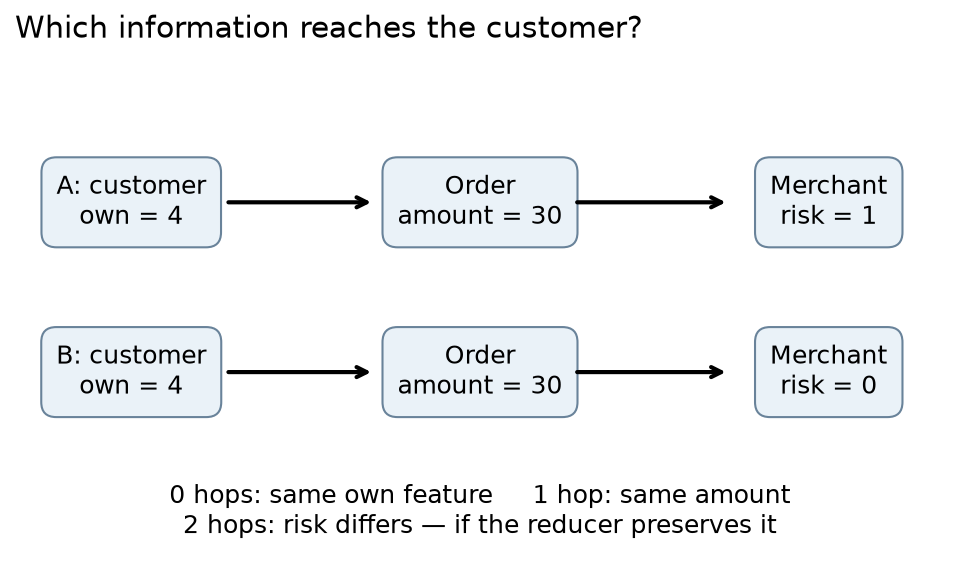</div><figcaption>Two illustrative database worlds. Own features and order amounts agree; merchant risk differs two edges away. This shows information access, without claiming every graph reducer preserves the signal.</figcaption></figure>

**Aggregation limits also apply to graph models.** If all messages are identical and a graph layer takes their mean, duplicating a neighbor may leave the representation unchanged. More relational access supplies candidate information; the encoding and aggregation still determine what survives. [Deep Sets](https://arxiv.org/abs/1703.06114) studies permutation-invariant functions on sets. It is a useful reading on this design problem; no Deep Sets benchmark is reproduced here.

**Rule constraints** restrict combinations of outputs. Suppose two bookings compete for one remaining seat. Independent high probabilities for both bookings do not enforce `accepted_A + accepted_B ≤ 1`. A shared allocation or constrained decision rule is needed. Features may encode seat availability, but a row-wise prediction loss alone gives no hard feasibility guarantee. Message passing alone gives no such guarantee either.



## 5 · Run the complete reproduction

The full construction uses **1,000 independent pairs per seed**, two customers per pair, three eligible events per customer, and two excluded events. Each pair shares a random base amount, positive increment and own-row feature. Its two histories reverse the same three values. IDs and physical row order are randomized and used only for routing.

**Split.** Shuffle pair groups using `split_seed = seed + 10000`. Put 60% of groups in training, 20% in validation and 20% in test. That yields 1,200 / 400 / 400 customers. Keeping each pair together makes every partition exactly balanced within each flat collision class. Different pairs can also collide; each contributes one label of each kind. Customers and their event rows never cross partitions.

**Held fixed.** Database, cutoff, pair partition, target, stump trainer and accuracy metric. **Varied.** Only whether delta is supplied. **Measured.** Train, validation and test accuracy, plus a post-freeze collision audit on test. Accuracy is the fraction of correct hard labels. Validation is reported as a diagnostic; the declared protocol makes no selection with it.

**Complete implementation.** The notebook exposes generation, eligibility, representations, splitting, fitting, prediction and evaluation. Three TODOs remain live in the actual runner. SQL provides an independent aggregation/ordering oracle, and a library decision tree checks the information-access control. Changing only excluded amounts must leave both representations unchanged.

**Author-reference evidence — measured locally; not output from your current kernel.**

| Seed | Flat test accuracy | Restored test accuracy | Exact ceilings, flat / restored |
|---|---|---|---|
| 0 | 0.500 | 1.000 | 0.500 / 1.000 |
| 1 | 0.500 | 1.000 | 0.500 / 1.000 |
| 2 | 0.500 | 1.000 | 0.500 / 1.000 |
| 3 | 0.500 | 1.000 | 0.500 / 1.000 |
| 4 | 0.500 | 1.000 | 0.500 / 1.000 |
| Mean ± sample SD | 0.500 ± 0.000 | 1.000 ± 0.000 | 0.500 / 1.000 |

SQL feature oracle, future/late-arrival invariance, pair isolation, storage-order invariance and independent depth-three tree control: **PASS**.


<figure class="ceiling-figure"><div tabindex="0" role="region" aria-label="Scrollable results figure">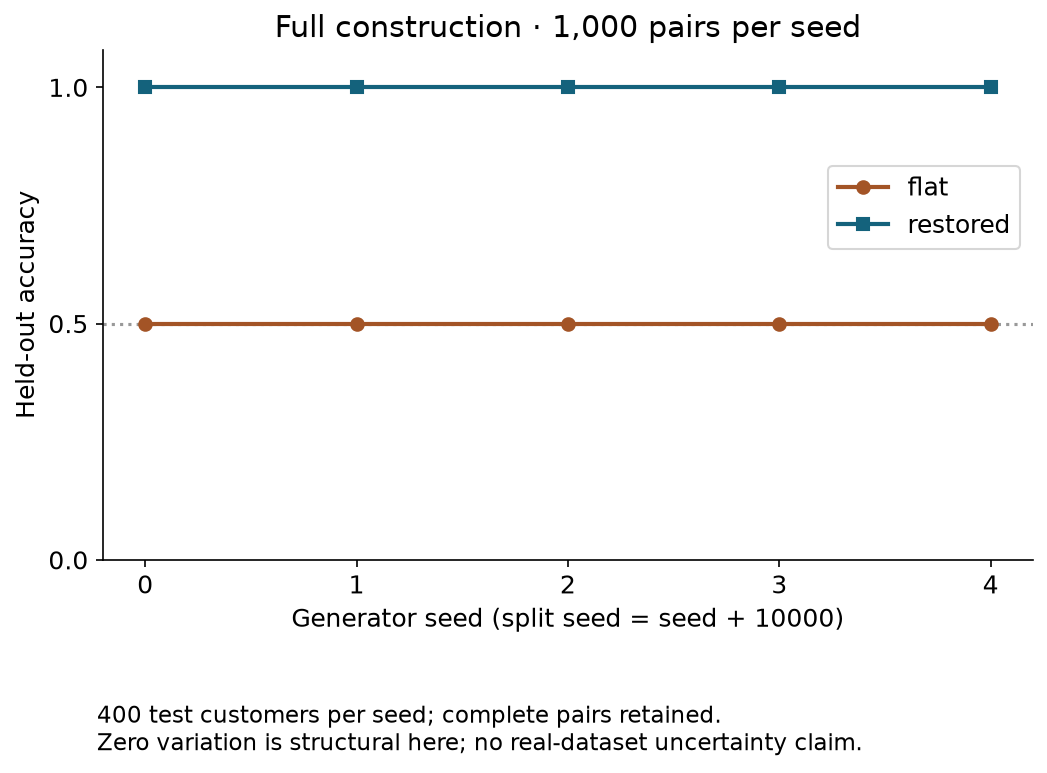</div><figcaption>Author-reference measurement: all five complete paired-history runs. Flat test accuracy 0.5; restored test accuracy 1.0. These are synthetic experiments under one generator.</figcaption></figure>

Five seeds vary the generated database and split, so these are five finite-support experiments under one generator. They are not five independent real datasets. Sample standard deviation describes those five runs; zero spread reflects the exact construction. It gives no estimate of a cross-domain RDL advantage. No significance test is needed to prove the collision argument.

**Reproduce locally:** from the repository root, run `.venv/bin/python labs/_verify_l077.py`. This executes all five full experiments and the independent checks. The notebook's final experiment uses the same pair count and seeds; it is not a smaller proxy.

[Open the lab](../labs/html/0077-single-table-ceiling.html) · [Download the notebook](../labs/0077-single-table-ceiling.ipynb) · [Protocol and commands](../labs/l077-reproduction.md) · [Machine-readable evidence](../labs/_verify_l077_results.json).



## 6 · Synthesize a claim that could fail

Separate three questions when carrying this result into real work:

1. **Information:** does the representation discard a variable required by the target? This lesson answers that exactly for one construction.
2. **Generalization:** do the accessible relationships remain predictive across new entities or time periods? Revisit [temporal splits in L055](../lessons/0055-tabred-temporal-splits.html) and [temporal shift in L068](../lessons/0068-pfns-under-temporal-shift.html). A collision proof cannot answer this.
3. **Operational cost:** what are the cost, latency and maintenance demands of computing or learning relational features? Revisit [L069's operating limits](../lessons/0069-tabpfn-open-environment-failures.html). A representation can be sufficient while its implementation is impractical.

The planned L056b/L069b extensions are not present as published lesson files here; these links point to the available related units. Their questions remain distinct from the information proof.

**A bounded thesis.** “For the paired-history generator and `[own,count,sum,mean,max]`, every deterministic row-only predictor has accuracy at most 0.5. Adding the eligible last-minus-first feature permits perfect classification.” You can refute an implementation of this thesis by producing a same-interface deterministic prediction vector with accuracy above its exact bound, or a wrong restoration result. Check IDs, cutoff, order, partition and labels before changing the theorem.

**A research hypothesis.** “On specified real temporal tasks, a learned relational model improves held-out performance over a tabular model with a declared feature-engineering budget, at acceptable inference cost.” This needs several real tasks, matched data access and tuning budgets, and a frozen evaluation protocol. Tabular models with adequate relational features, weak or unstable links, and restrictive graph reducers are potential counter-evidence.

[RelBench v1](https://arxiv.org/html/2407.20060v1) supplies real predictive tasks and comparisons against feature-engineered tabular models. Those empirical claims require their own reproduction. [L076's full historical replay](../labs/l076-reproduction.md) names a published target and contains the complete archived model/trainer with local, Colab and Modal operators. That benchmark remains **NOT_RUN** in the saved L076 evidence. This lesson's exact synthetic results do not fill that gap.



## EXIT · submit a ceiling certificate

Complete the notebook's three TODOs and all CHECK cells. Submit the saved five-seed results together with 150–250 words containing: your exact input vector; two colliding histories with labels; the bound and its assumptions; the feature that repairs it; and one real-data experiment that could weaken the broader relational thesis.

Then create a new collision: preserve count and sum while changing a target you define. State whether your current repair feature distinguishes it. Explain why a perfect lookup using unique IDs would leave new-entity generalization unresolved.



**Reading route.** Start with the [Fey et al. position paper](https://proceedings.mlr.press/v235/fey24a.html) for the relational learning motivation, then [RelBench's user-study design](https://arxiv.org/html/2407.20060v1#S6) for the empirical test it demands. Ask the teaching agent about any step you cannot derive; send your certificate for grading. Authored material and passing checks do not record learner mastery.

**Next conceptual step.** L078 develops message passing: specify which record sends a message, which neighbors receive it, and what their reduction preserves. Keep this lesson's question beside every graph layer: which different histories still produce the same representation?


<a id="lab-exercises"></a>
## Implement and certify the information interface

The next cells show the complete generator, split, eligibility filter, model and training loop. Your three TODO functions remain live in `run_experiment`. The notebook imports no hidden experiment model. Work in `labs/` locally; the bootstrap selects it on Colab.

In [ ]:
import hashlib
import json
import numpy as np
from pathlib import Path

### PROVIDED · make_database

The target describes eligible history direction. Random metadata never enters a predictor. Each excluded record deliberately probes a time boundary.

In [ ]:
def make_database(n_pairs=1000, seed=0):
    """Opposite histories share every flat feature. IDs are metadata, never inputs."""
    if n_pairs < 10:
        raise ValueError('Use at least ten pairs for nonempty partitions')
    rng = np.random.default_rng(seed)
    ids = rng.permutation(np.arange(10001, 10001 + 2*n_pairs))
    customers, events = [], []
    for pair in range(n_pairs):
        base, step = int(rng.integers(10, 101)), int(rng.integers(1, 21))
        own = int(rng.integers(0, 10))
        for target in (0, 1):
            cid = int(ids[2*pair + target])
            customers.append(dict(customer_id=cid, pair_id=pair, own=own, target=target))
            amounts = [base, base+step, base+2*step]
            if target == 0:
                amounts.reverse()
            for day, amount in enumerate(amounts, 1):
                events.append(dict(customer_id=cid,event_day=day,available_day=day,amount=amount))
            # Both must be invisible at cutoff10, including the old but late row.
            events.append(dict(customer_id=cid,event_day=12,available_day=12,amount=10000))
            events.append(dict(customer_id=cid,event_day=2,available_day=11,amount=-10000))
    rng.shuffle(customers)
    rng.shuffle(events)
    return customers, events

### PROVIDED · split_pairs

Pairs are grouping units. Keeping each pair together preserves exact conditional balance in every partition.

In [ ]:
def split_pairs(customers, seed=0):
    """60/20/20 disjoint pair groups. Test is untouched during fitting."""
    groups = np.unique([c['pair_id'] for c in customers])
    groups = np.random.default_rng(seed+10000).permutation(groups)
    a, b = int(.6*len(groups)), int(.8*len(groups))
    return tuple(np.array([i for i,c in enumerate(customers) if c['pair_id'] in set(part)],dtype=int)
                 for part in (groups[:a],groups[a:b],groups[b:]))

### PROVIDED · eligible_histories

This is the shared identity and time boundary. FKs must refer to known PKs; both event and availability times are checked.

In [ ]:
def eligible_histories(customers, events, cutoff):
    """Map identity to eligible rows; protect both event time and availability."""
    groups = {c['customer_id']: [] for c in customers}
    if len(groups) != len(customers):
        raise ValueError('Customer primary keys must be unique')
    for e in events:
        if e['customer_id'] not in groups:
            raise ValueError('Unknown customer foreign key')
        if e['event_day'] <= cutoff and e['available_day'] <= cutoff:
            groups[e['customer_id']].append(e)
    return groups

### TODO · flat_rows

Construct five columns in customer order: own, count, sum, mean and maximum of eligible amounts. Use the provided identity/eligibility helper. Empty-history aggregates are zero. IDs and labels must stay outside the feature vector.

Predict the hand fixture output before running the CHECK.

In [ ]:
def flat_rows(customers, events, cutoff):
    raise NotImplementedError("Implement flat_rows")

In [ ]:
# CHECK — do not edit
c=[dict(customer_id=9,own=4),dict(customer_id=2,own=7)]
e=[dict(customer_id=9,event_day=3,available_day=3,amount=8),dict(customer_id=9,event_day=1,available_day=1,amount=2),dict(customer_id=9,event_day=2,available_day=11,amount=99)]
assert np.array_equal(flat_rows(c,e,10),[[4,2,10,5,8],[7,0,0,0,0]]), 'Check eligibility, row order and empty history'
assert np.array_equal(flat_rows(c[::-1],e[::-1],10),[[7,0,0,0,0],[4,2,10,5,8]]), 'Route by identity'
print('CHECK: eligible aggregation and empty histories pass')

### TODO · collision_ceiling

Partition examples by exactly equal feature vectors and return the best fraction of correct labels possible with one prediction per vector. Support arbitrary class proportions. Reject empty or misaligned inputs and nonfinite features.

Predict the hand fixture output before running the CHECK.

In [ ]:
def collision_ceiling(x, y):
    raise NotImplementedError("Implement collision_ceiling")

In [ ]:
# CHECK — do not edit
assert collision_ceiling([[1],[1]],[0,1])==.5, 'Identical inputs need one prediction'
assert collision_ceiling([[1],[1],[1],[2]],[0,0,1,1])==.75, 'Weight by examples, not classes'
assert collision_ceiling([[1],[2]],[0,1])==1., 'Unique rows give an empirical ceiling of one'
for xx,yy in [([],[]),([[0]],[0,1]),([[float('nan')]],[0])]:
    try: collision_ceiling(xx,yy)
    except ValueError: pass
    else: raise AssertionError('Reject undefined input')
print('CHECK: exact majority-class ceiling passes')

### TODO · temporal_delta

Return last-minus-first eligible amount for each customer, using event time rather than physical row order. Empty and singleton histories give zero. Reject tied eligible event times because the fixture declares no tie-breaking order.

Predict the hand fixture output before running the CHECK.

In [ ]:
def temporal_delta(customers, events, cutoff):
    raise NotImplementedError("Implement temporal_delta")

In [ ]:
# CHECK — do not edit
assert temporal_delta(c,e,10).tolist()==[6,0], 'Sort eligible events by event time'
assert temporal_delta(c,e[::-1],10).tolist()==[6,0], 'Storage order has no meaning'
tied=e+[dict(customer_id=9,event_day=1,available_day=1,amount=5)]
try: temporal_delta(c,tied,10)
except ValueError: pass
else: raise AssertionError('Tied eligible times need a declared rule')
print('CHECK: time order, availability and ambiguity pass')

### PROVIDED · fit_stump

Every threshold is derived from training values. Both orientations are tested; ties use the first candidate. This is the entire training procedure.

In [ ]:
def fit_stump(x, y):
    """Train a depth-one classifier by exhaustive threshold search; ties stay first."""
    x, y = np.asarray(x), np.asarray(y)
    best, best_correct = None, -1
    for col in range(x.shape[1]):
        values = np.unique(x[:,col])
        thresholds = np.r_[values[0]-1,(values[:-1]+values[1:])/2,values[-1]+1]
        for threshold in thresholds:
            for right_label in (0,1):
                pred = np.where(x[:,col]>threshold,right_label,1-right_label)
                correct = int(np.sum(pred==y))
                if correct > best_correct:
                    best_correct = correct
                    best = dict(column=col,threshold=float(threshold),right_label=right_label)
    return best

### PROVIDED · predict_stump

One threshold comparison per row. The function sees only a model and its supplied feature matrix.

In [ ]:
def predict_stump(model, x):
    """Prediction consumes only the supplied row; no label/ID lookup."""
    return np.where(np.asarray(x)[:,model['column']]>model['threshold'],
                    model['right_label'],1-model['right_label'])

### PROVIDED · run_experiment

The runner resolves your three helpers above. It fits on training, then reports validation/test scores. The ceiling audit consumes test labels only after fitting.

In [ ]:
def run_experiment(n_pairs=1000, seed=0):
    """One full protocol run; all representations use the student's live helpers."""
    customers, events = make_database(n_pairs,seed)
    train, valid, test = split_pairs(customers,seed)
    y = np.array([c['target'] for c in customers])
    flat = flat_rows(customers,events,10)
    restored = np.column_stack([flat,temporal_delta(customers,events,10)])
    scores, models, ceilings = {}, {}, {}
    for name, x in [('flat',flat),('restored',restored)]:
        model = fit_stump(x[train],y[train])
        models[name] = model
        scores[name] = {part:float(np.mean(predict_stump(model,x[idx])==y[idx]))
                       for part,idx in [('train',train),('validation',valid),('test',test)]}
        # Audit uses test labels AFTER model freeze; never a training input.
        ceilings[name] = collision_ceiling(x[test],y[test])
    digest = hashlib.sha256(json.dumps([customers,events],sort_keys=True).encode()).hexdigest()
    return dict(seed=seed,split_seed=seed+10000,n_pairs=n_pairs,cutoff=10,
                split_rows=[len(train),len(valid),len(test)],dataset_sha256=digest,
                scores=scores,models=models,ceilings=ceilings)

### CHECK · a prediction-time intervention

Predict the effect of replacing every future or late-arriving amount with a million. Then reverse physical storage order. Both representations must be unchanged after accounting for customer order.

In [ ]:
customers,events=make_database(30,77)
flat=flat_rows(customers,events,10)
delta=temporal_delta(customers,events,10)
changed=[dict(e,amount=1e6) if e['event_day']>10 or e['available_day']>10 else dict(e) for e in events]
assert np.array_equal(flat,flat_rows(customers,changed,10)), 'Excluded events changed flat features'
assert np.array_equal(delta,temporal_delta(customers,changed,10)), 'Excluded events changed delta'
assert np.array_equal(delta[::-1],temporal_delta(customers[::-1],events[::-1],10)), 'Identity or order bug'
train,valid,test=split_pairs(customers,77)
pair_sets=[{customers[i]['pair_id'] for i in part} for part in (train,valid,test)]
assert not(pair_sets[0]&pair_sets[1] or pair_sets[0]&pair_sets[2] or pair_sets[1]&pair_sets[2])
y=np.array([c['target'] for c in customers])
for part in (train,valid,test): assert collision_ceiling(flat[part],y[part])==.5
print('CHECK: invariance and pair-group isolation pass')

### EXIT · your ceiling certificate

Write 150–250 words: name the exact feature interface, exhibit opposite-label histories, derive the bound, describe a permissible repair, and propose a real-data test that could weaken the broader thesis. Then construct another collision preserving count and sum. Explain whether delta repairs your new target. Send this text with the JSON below for grading; code execution alone does not grade the explanation.

## NEXT STEP · reproduce the complete declared experiment

Run all five seeds below. This is the same 1,000-pair protocol as the author reference, with no downloads, GPU or additional model package. Train/validation/test sizes are 1,200/400/400 per seed. Every displayed result below comes from your live functions. Allow roughly a minute on a small CPU. The tolerance is exact accuracy equality: 0.5 flat and 1.0 restored.

In [ ]:
runs=[run_experiment(1000,seed) for seed in range(5)]
print('seed | flat test | restored test | flat bound | restored bound')
for r in runs:
    print(f"{r['seed']:4d} | {r['scores']['flat']['test']:.3f}     | {r['scores']['restored']['test']:.3f}         | {r['ceilings']['flat']:.3f}      | {r['ceilings']['restored']:.3f}")
    assert r['scores']['flat']['test']==r['ceilings']['flat']==.5
    assert r['scores']['restored']['test']==r['ceilings']['restored']==1.
Path('l077-student-results.json').write_text(json.dumps(runs,indent=2)+'\n')
print('MATCH: complete declared synthetic experiment; no published benchmark reproduction claimed.')

### Conclusion ledger

| Bucket | Status | What this establishes |
|---|---|---|
| Local construction | Recompute above | Exact information ceiling and successful feature repair under the declared generator |
| Published RelBench results | Cited, NOT_RUN here | Real-data predictive comparisons require their own protocol |
| Larger synthetic run | Full declared run above | All 1,000 pairs per seed; increasing this count cannot establish real-world prevalence |

For the real-data sequel, use [L076's complete historical model/trainer notebook](../labs/html/0076-encoder-predictor-stack.html) and its [pinned replay contract](../labs/l076-reproduction.md), which include local, Colab and Modal commands. This synthesis introduces no replacement model and does not relabel that unrun benchmark as reproduced.

**Spaced retrieval:** tomorrow, derive the majority-class bound without opening this notebook. One week later, give a counterexample to the claim that a graph always preserves cardinality.